## **Modelo Predictivo para Tamizaje de Cáncer de Páncreas (PDAC) usando Biomarcadores**

En este notebook se desarrolla un modelo de regresión logística orientado a la predicción de cáncer de páncreas (PDAC) a partir de información clínica básica y biomarcadores séricos.

El trabajo incluye:
- análisis exploratorio univariado y bivariado,
- evaluación de supuestos estadísticos,
- construcción de modelos de regresión logística,
- selección manual de variables mediante criterios de verosimilitud y parsimonia,
- evaluación del desempeño predictivo con foco en un escenario de tamizaje.

**Instalación de paquetes**

In [ ]:
!pip -q install pandas numpy scipy statsmodels scikit-learn matplotlib seaborn ydata-profiling

**Imports**

In [ ]:
import os
import numpy as np
import pandas as pd

from scipy import stats
from statsmodels.stats.diagnostic import lilliefors
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
sns.set_context("notebook")

**Lectura + exploración inicial**

In [ ]:
# Montar Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
base = "/content/drive/MyDrive"
for root, dirs, files in os.walk(base):
    for f in files:
        if f.lower() == "cancer_pancreas.csv":
            print(os.path.join(root, f))

/content/drive/MyDrive/Estudios/Posgrado Austral/Proyectos/cancer_pancreas.csv


In [ ]:
path = "/content/drive/MyDrive/Estudios/Posgrado Austral/Proyectos/cancer_pancreas.csv"
datos = pd.read_csv(path, sep=";", decimal=",")

# Dataset: dimensiones y primeras filas
print("Dimensión (filas, columnas):", datos.shape)
display(datos.head())

Dimensión (filas, columnas): (274, 7)


,Estatus_paciente,Edad,Sexo,Creatinina,LYVE1,REG1B,TFF1
0,Control,48,Mujer,3.44955,4.512589,138.79873,1876.588322
1,Control,62,Varon,1.93401,7.069545,281.41368,1425.501010
2,Control,48,Mujer,1.05183,7.300192,118.32500,1424.961000
3,Control,44,Mujer,2.02449,6.925281,53.11000,1274.490000
4,Control,89,Mujer,0.64467,6.836843,76.83400,981.545000


El dataset tiene **274 observaciones** y **7 variables**. La variable resultado es `Estatus_paciente` (con categorías PDAC vs Control). El resto son covariables demográficas (Edad, Sexo) y biomarcadores (Creatinina, LYVE1, REG1B y TFF1).


**Split Train/Test**

In [ ]:
train_df, test_df = train_test_split(
    datos,
    test_size=0.30,
    stratify=datos["y_pdac"],
    random_state=42
)

print("Train:", train_df.shape, "PDAC%:", round(train_df["y_pdac"].mean(), 3))
print("Test :", test_df.shape,  "PDAC%:", round(test_df["y_pdac"].mean(), 3))

Train: (191, 9) PDAC%: 0.33
Test : (83, 9) PDAC%: 0.337


**Tipos de variables y valores faltantes**

In [ ]:
def skim_like(df: pd.DataFrame):
    out = []
    for col in df.columns:
        s = df[col]
        out.append({
            "variable": col,
            "dtype": str(s.dtype),
            "missing_n": int(s.isna().sum()),
            "missing_%": round(float(s.isna().mean()*100), 2),
            "n_unique": int(s.nunique(dropna=True)),
            "example": s.dropna().iloc[0] if s.dropna().shape[0] else np.nan
        })
    return pd.DataFrame(out)

skim_like(datos)

,variable,dtype,missing_n,missing_%,n_unique,example
0,Estatus_paciente,object,0,0.0,2,Control
1,Edad,int64,0,0.0,56,48
2,Sexo,object,0,0.0,2,Mujer
3,Creatinina,float64,0,0.0,137,3.44955
4,LYVE1,float64,0,0.0,255,4.512589
5,REG1B,float64,0,0.0,270,138.79873
6,TFF1,float64,0,0.0,261,1876.588322


Las variables numéricas (con formato int o float) son `Edad`, `Creatinina`, `LYVE1`, `REG1B` y `TFF1`.

Las variables categóricas (`Estatus_paciente`, `Sexo`) están inicialmente como object. Deben transformarse para el modelado.

La variable de resultado, `Estatus_paciente`, presenta dos categorías (PDAC y Control), coherentes con un diseño de tipo casos–controles.

No hay valores faltantes en ninguna variable (0% de missing en todas).

**Distribución de la variable resultado (`Estatus_paciente`)**

**Univariado/bivariado (categóricas)**

In [ ]:
def freq_table(s: pd.Series):
    tab = s.value_counts(dropna=False).rename("n").to_frame()
    tab["Frecuencia_relativa"] = (tab["n"] / tab["n"].sum() * 100).round(1)
    return tab

freq_table(datos["Estatus_paciente"])

,n,Frecuencia_relativa
Estatus_paciente,,
Control,183,66.8
PDAC,91,33.2


183 pacientes (**66,8 %**) corresponden al grupo Control, mientras que 91 pacientes (**33,2 %**) presentan PDAC (2 pacientes por cada control).

In [ ]:
freq_table(datos["Sexo"])

,n,Frecuencia_relativa
Sexo,,
Mujer,150,54.7
Varon,124,45.3


150 pacientes (**54,7%**) son mujeres, con una distribución por sexo relativamente equilibrada.

In [ ]:
# Asociación entre Sexo y Estatus del paciente
ct = pd.crosstab(datos["Sexo"], datos["Estatus_paciente"], margins=True)
ct

Estatus_paciente,Control,PDAC,All
Sexo,,,
Mujer,115,35,150
Varon,68,56,124
All,183,91,274


In [ ]:
ct_colpct = pd.crosstab(datos["Sexo"], datos["Estatus_paciente"], normalize="columns") * 100
ct_colpct = ct_colpct.round(1)
ct_colpct

Estatus_paciente,Control,PDAC
Sexo,,
Mujer,62.8,38.5
Varon,37.2,61.5


Entre los controles, la mayoría son mujeres (**62,8%**), mientras que entre los pacientes con PDAC predominan los varones (**61,5%**). Esta diferencia sugiere una posible asociación entre el sexo masculino y la presencia de PDAC en la muestra.

In [ ]:
# Chi-cuadrado Sexo vs Estatus
tabla = pd.crosstab(datos["Sexo"], datos["Estatus_paciente"])
chi2, p, dof, expected = stats.chi2_contingency(tabla)
{"chi2": chi2, "p_value": p, "dof": dof}

{'chi2': np.float64(13.613874816058845),
 'p_value': np.float64(0.00022452000835835364),
 'dof': 1}

La prueba chi-cuadrado de independencia muestra una asociación estadísticamente significativa entre el sexo y el estatus del paciente (χ² = 13,61; gl = 1; p < 0,001).

Esto indica que la distribución de PDAC y Control no es independiente del sexo, observándose una mayor proporción de varones entre los casos de PDAC, y sugiriendo al Sexo como potencial factor asociado al riesgo de PDAC.

**Variables numéricas**

In [ ]:
datos.select_dtypes(include=[np.number]).describe().T

,count,mean,std,min,25%,50%,75%,max
Edad,274.0,59.361314,12.370832,26.000000,51.000000,59.000000,68.000000,89.00000
Creatinina,274.0,0.822369,0.581476,0.067860,0.364748,0.701220,1.114035,3.44955
LYVE1,274.0,2.586241,3.224551,0.000129,0.008727,1.150142,4.237025,15.27052
REG1B,274.0,87.525855,153.689715,0.001104,8.469358,29.619046,97.816508,950.08000
TFF1,274.0,456.082823,797.847963,0.005293,22.648825,155.768375,469.666431,6035.15700


`Edad` muestra una distribución relativamente concentrada y simétrica, con una media de 59,4 años y una mediana de 59 años. El rango etario va de 26 a 89 años (estudio en población adulta).

**Creatinina** presenta una media de 0,82 y una mediana de 0,70, con valores máximos elevados en relación con los percentiles superiores, lo que indica una posible asimetría a derecha y la presencia de valores altos extremos.

`LYVE1`, `REG1B `y `TFF1` tienen una marcada asimetría positiva, evidenciada por medianas muy inferiores a las medias, rangos amplios y valores máximos considerablemente mayores que el tercer cuartil. `REG1B` y `TFF1` presentan una dispersión muy elevada y valores extremos pronunciados, lo que sugiere distribuciones altamente sesgadas.


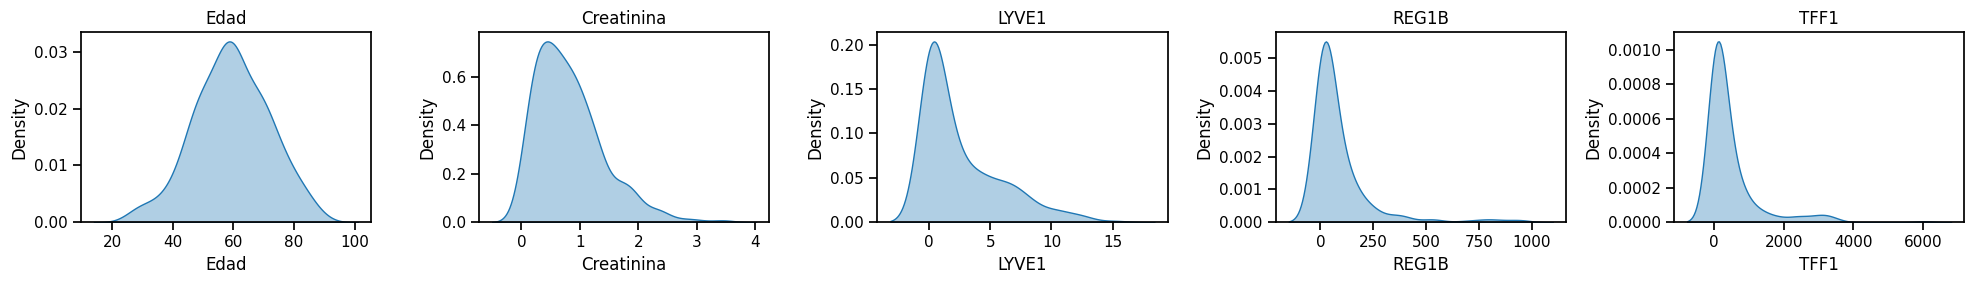

In [ ]:
# Densidades (Edad, Creatinina, LYVE1, REG1B, TFF1)
vars_num = ["Edad", "Creatinina", "LYVE1", "REG1B", "TFF1"]

fig, axes = plt.subplots(1, len(vars_num), figsize=(4*len(vars_num), 3))
for ax, v in zip(axes, vars_num):
    sns.kdeplot(data=datos, x=v, fill=True, alpha=0.35, ax=ax)
    ax.set_title(v)
plt.tight_layout()
plt.show()

`Edad` presenta una distribución relativamente simétrica y unimodal, sin colas extremas pronunciadas, lo que sugiere un comportamiento cercano a la normalidad en la muestra estudiada.

`Creatinina` muestra una asimetría positiva, con mayor concentración de valores bajos y una cola derecha más extendida, compatible con la presencia de valores elevados poco frecuentes.

`LYVE1`,`REG1B` y `TFF1` tienen distribuciones fuertemente sesgadas a la derecha, con alta densidad en valores bajos y colas largas hacia valores altos. Este patrón es típico de biomarcadores biológicos y explica la gran diferencia entre medias y medianas observada previamente.

In [ ]:
# Helpers (Lilliefors, QQ, var test, t-test, Mann-Whitney)
def lillie_by_group(df, var, group="Estatus_paciente", g1="PDAC", g2="Control"):
    x1 = df.loc[df[group] == g1, var].dropna().astype(float)
    x2 = df.loc[df[group] == g2, var].dropna().astype(float)
    stat1, p1 = lilliefors(x1.values)
    stat2, p2 = lilliefors(x2.values)
    return pd.DataFrame({
        "grupo": [g1, g2],
        "Lilliefors_stat": [stat1, stat2],
        "p_value": [p1, p2],
        "n": [len(x1), len(x2)]
    })

def qqplot_series(x, title="QQ plot"):
    sm.ProbPlot(pd.Series(x).dropna()).qqplot(line="s")
    plt.title(title)
    plt.show()

def f_test_equal_var(x1, x2):
    # equivalente conceptual a var.test en R para normalidad; si no hay normalidad, preferí Levene/Brown-Forsythe.
    x1 = np.asarray(pd.Series(x1).dropna())
    x2 = np.asarray(pd.Series(x2).dropna())
    f = np.var(x1, ddof=1) / np.var(x2, ddof=1)
    dfn, dfd = len(x1)-1, len(x2)-1
    p = 2 * min(stats.f.cdf(f, dfn, dfd), 1 - stats.f.cdf(f, dfn, dfd))
    return {"F": f, "df1": dfn, "df2": dfd, "p_value": p}

def t_test_equal_var(x1, x2):
    x1 = pd.Series(x1).dropna().astype(float)
    x2 = pd.Series(x2).dropna().astype(float)
    t, p = stats.ttest_ind(x1, x2, equal_var=True)
    return {"t": t, "p_value": p}

def wilcoxon_rank_sum(x1, x2):
    # Mann-Whitney U (equivalente a wilcox.test entre grupos independientes)
    x1 = pd.Series(x1).dropna().astype(float)
    x2 = pd.Series(x2).dropna().astype(float)
    u, p = stats.mannwhitneyu(x1, x2, alternative="two-sided")
    return {"U": u, "p_value": p}

In [ ]:
## Variable Edad
datos.groupby("Estatus_paciente")["Edad"].agg(["mean", "median", "count"])

,mean,median,count
Estatus_paciente,,,
Control,56.333333,57.0,183
PDAC,65.450549,67.0,91


Los pacientes con PDAC presentan una edad promedio y mediana significativamente mayores que los controles. La diferencia es consistente tanto en la media (≈ 9 años) como en la mediana (10 años).

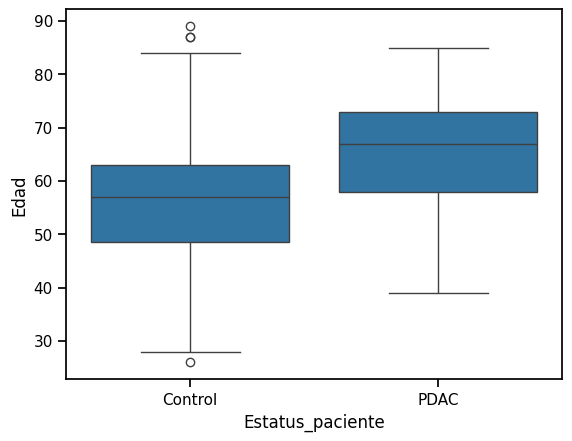

In [ ]:
sns.boxplot(data=datos, x="Estatus_paciente", y="Edad")
plt.show()

El boxplot evidencia un desplazamiento claro de la distribución de edad hacia valores mayores en el grupo PDAC, con escaso solapamiento entre los rangos intercuartílicos de ambos grupos.

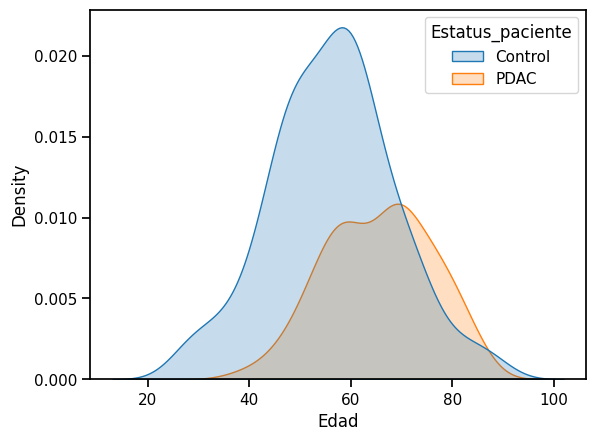

In [ ]:
sns.kdeplot(data=datos, x="Edad", hue="Estatus_paciente", fill=True, alpha=0.25)
plt.show()

Las curvas de densidad confirman que la distribución de edad en pacientes con PDAC está desplazada hacia la derecha respecto del grupo Control.

In [ ]:
lillie_by_group(datos, "Edad")

,grupo,Lilliefors_stat,p_value,n
0,PDAC,0.076029,0.246445,91
1,Control,0.046518,0.477523,183


No se rechaza la hipótesis de normalidad en ninguno de los dos grupos (p > 0,05), lo que habilita el uso de pruebas paramétricas para la comparación de medias.

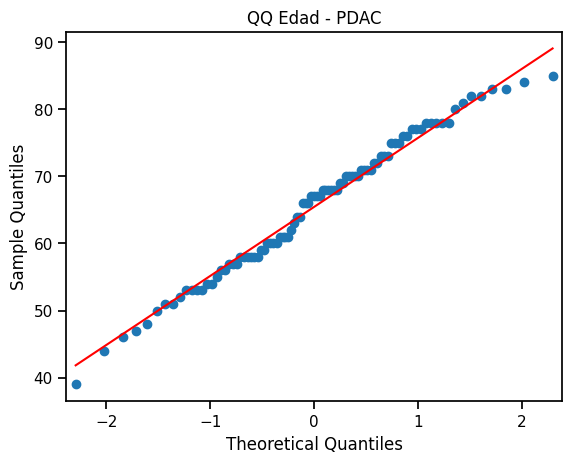

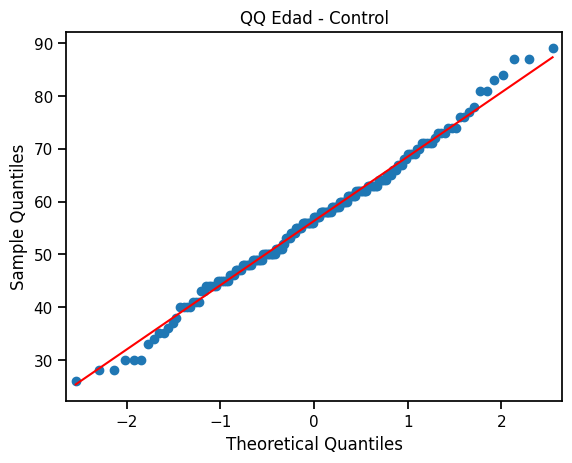

In [ ]:
qqplot_series(datos.loc[datos["Estatus_paciente"]=="PDAC", "Edad"], "QQ Edad - PDAC")
qqplot_series(datos.loc[datos["Estatus_paciente"]=="Control", "Edad"], "QQ Edad - Control")

Los gráficos Q–Q muestran una adecuada alineación de los cuantiles observados con los esperados bajo normalidad, sin desviaciones sistemáticas relevantes en colas, reforzando los resultados del test de Lilliefors.

In [ ]:
x_pdac = datos.loc[datos["Estatus_paciente"]=="PDAC", "Edad"]
x_ctrl = datos.loc[datos["Estatus_paciente"]=="Control", "Edad"]

f_test_equal_var(x_pdac, x_ctrl)

{'F': np.float64(0.7183209925135094),
 'df1': 90,
 'df2': 182,
 'p_value': np.float64(0.07929687959538713)}

No se detectan diferencias estadísticamente significativas entre las varianzas de ambos grupos (p > 0,05), por lo que se asume homocedasticidad.

In [ ]:
# t-test para muestras independientes (varianzas iguales)
t_test_equal_var(x_pdac, x_ctrl)

{'t': np.float64(6.116793030960099),
 'p_value': np.float64(3.3103279416867147e-09)}

La prueba t para muestras independientes muestra una diferencia estadísticamente significativa en la edad media entre pacientes con PDAC y controles (p < 0,001). Este resultado indica que la edad está fuertemente asociada con la presencia de PDAC en la muestra analizada.

In [ ]:
## Creatinina / LYVE1 / REG1B / TFF1


====================== Creatinina ======================
                      mean   median  count
Estatus_paciente                          
Control           0.797633  0.71253    183
PDAC              0.872113  0.70122     91


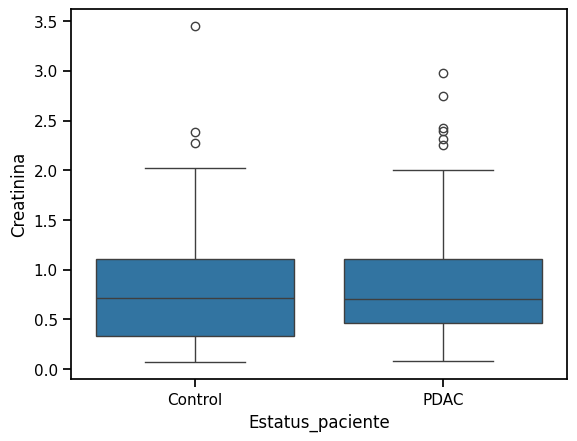

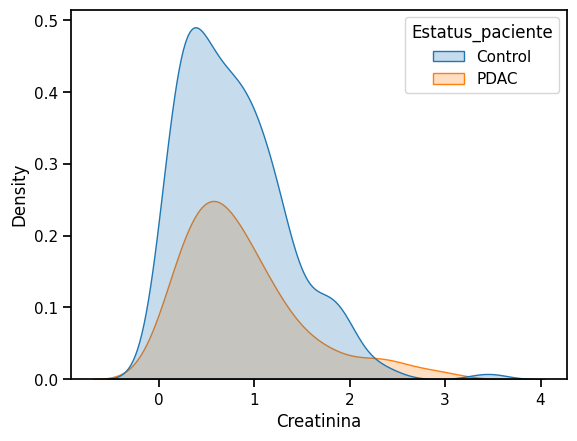

     grupo  Lilliefors_stat  p_value    n
0     PDAC         0.136060    0.001   91
1  Control         0.095947    0.001  183
Wilcoxon/Mann-Whitney: {'U': np.float64(8820.0), 'p_value': np.float64(0.42482035251270944)}

====================== LYVE1 ======================
                      mean    median  count
Estatus_paciente                           
Control           1.212887  0.145589    183
PDAC              5.348041  5.160876     91


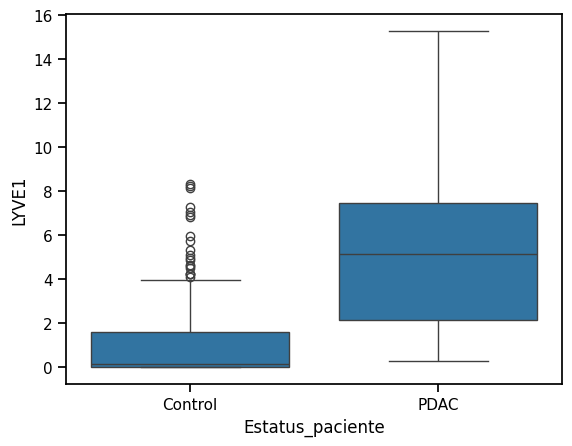

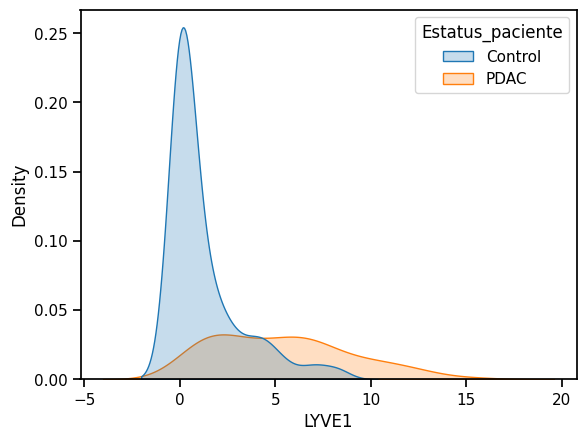

     grupo  Lilliefors_stat   p_value    n
0     PDAC         0.090925  0.074992   91
1  Control         0.263364  0.001000  183
Wilcoxon/Mann-Whitney: {'U': np.float64(14666.0), 'p_value': np.float64(1.0532839707676395e-24)}

====================== REG1B ======================
                        mean     median  count
Estatus_paciente                              
Control            41.327901   17.58337    183
PDAC              180.429433  106.81930     91


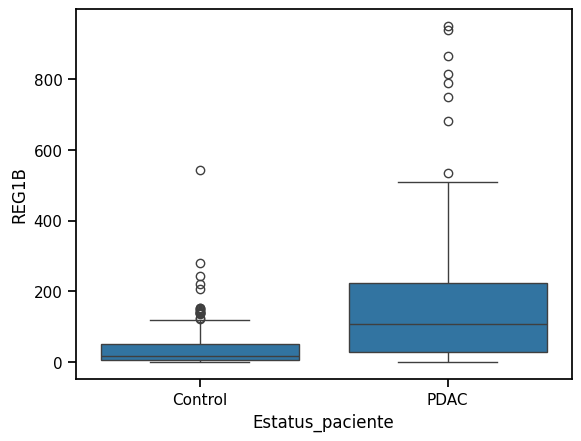

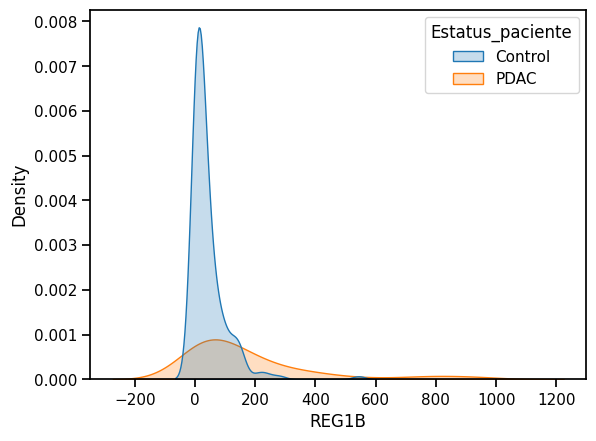

     grupo  Lilliefors_stat  p_value    n
0     PDAC         0.213935    0.001   91
1  Control         0.252022    0.001  183
Wilcoxon/Mann-Whitney: {'U': np.float64(12897.0), 'p_value': np.float64(1.386030235311682e-13)}

====================== TFF1 ======================
                        mean    median  count
Estatus_paciente                             
Control            169.02414   59.7930    183
PDAC              1033.35468  605.4024     91


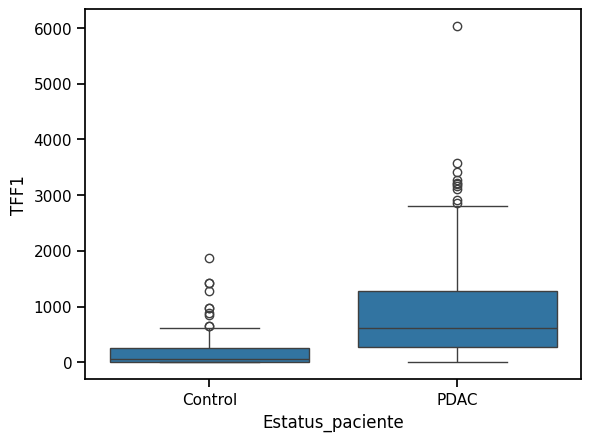

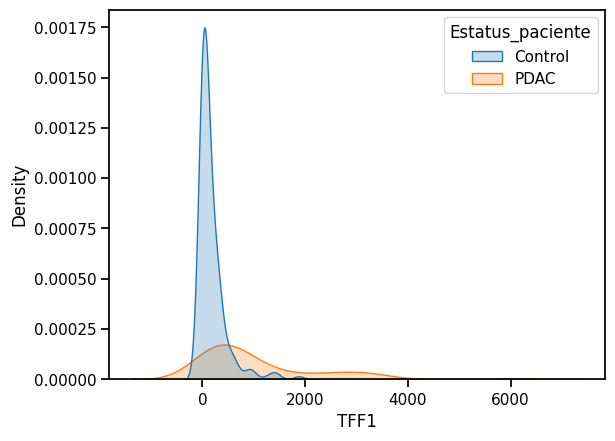

     grupo  Lilliefors_stat  p_value    n
0     PDAC         0.215339    0.001   91
1  Control         0.271752    0.001  183
Wilcoxon/Mann-Whitney: {'U': np.float64(14182.0), 'p_value': np.float64(2.5977660421591818e-21)}


In [ ]:
for v in ["Creatinina", "LYVE1", "REG1B", "TFF1"]:
    print("\n======================", v, "======================")
    print(datos.groupby("Estatus_paciente")[v].agg(["mean","median","count"]))

    sns.boxplot(data=datos, x="Estatus_paciente", y=v)
    plt.show()

    sns.kdeplot(data=datos, x=v, hue="Estatus_paciente", fill=True, alpha=0.25)
    plt.show()

    print(lillie_by_group(datos, v))

    x_pdac = datos.loc[datos["Estatus_paciente"]=="PDAC", v]
    x_ctrl = datos.loc[datos["Estatus_paciente"]=="Control", v]
    print("Wilcoxon/Mann-Whitney:", wilcoxon_rank_sum(x_pdac, x_ctrl))



*   **`Creatinina`**: la prueba de Lilliefors rechaza la normalidad en ambos grupos (p < 0,01), por lo que se descarta el uso de pruebas paramétricas. La prueba de Mann–Whitney (Wilcoxon rank-sum) no muestra diferencias estadísticamente significativas entre grupos (p = 0,425). No se observa evidencia de una asociación significativa entre los niveles de creatinina y el estatus de PDAC en la muestra analizada.
*   **`LYVE1`**: la normalidad es rechazada en ambos grupos (p < 0,01), con una marcada asimetría positiva. La prueba de Mann–Whitney muestra una diferencia altamente significativa entre grupos
(p < 1×10⁻²³). Los pacientes con PDAC presentan concentraciones de LYVE1 sustancialmente mayores que los controles.
*   **`REG1B`**: se rechaza la normalidad en ambos grupos (p < 0,01), con colas derechas muy pronunciadas. La prueba de Mann–Whitney indica una diferencia estadísticamente significativa
(p < 1×10⁻¹²). Los niveles de REG1B son significativamente más elevados en pacientes con PDAC.
*   **`TFF1`**: la distribución de TFF1 es fuertemente asimétrica en ambos grupos, rechazándose la normalidad (p < 0,01). La prueba de Mann–Whitney muestra una diferencia altamente significativa entre PDAC y Control (p < 1×10⁻²⁰). Los pacientes con PDAC presentan valores de TFF1 notablemente superiores a los controles

Estos hallazgos respaldan la inclusión de LYVE1, REG1B y TFF1 como candidatos relevantes en los modelos de regresión logística.


**Preparación de variables para el modelado: factorización (categorías) y outcome binario**

In [ ]:
datos["Estatus_paciente"] = datos["Estatus_paciente"].astype("category")
datos["Sexo"] = datos["Sexo"].astype("category")

# Outcome binario: PDAC=1, Control=0
datos["y_pdac"] = (datos["Estatus_paciente"].astype(str) == "PDAC").astype(int)

datos[["Estatus_paciente","y_pdac","Sexo"]].head()

,Estatus_paciente,y_pdac,Sexo
0,Control,0,Mujer
1,Control,0,Varon
2,Control,0,Mujer
3,Control,0,Mujer
4,Control,0,Mujer


Las variables `Estatus_paciente` y `Sexo` se convirtieron a tipo categórico para su correcta inclusión dentro de los modelos estadísticos.

Se definió una variable binaria `y_pdac`, donde:
*   1 indica presencia de PDAC,
*   0 indica condición Control.

Esta codificación explicita el evento que se desea modelar (probabilidad de PDAC) y facilita la interpretación de los coeficientes de la regresión logística: OR mayores a 1 indican un aumento en la probabilidad de PDAC, mientras que valores menores a 1 indican un efecto protector.

**Regresión logística simple (univariadas) + OR**

In [ ]:
def fit_logit(formula, df):
    # GLM binomial (similar a glm(..., family=binomial) en R)
    m = smf.glm(formula=formula, data=df, family=sm.families.Binomial()).fit()
    return m

def or_table(model):
    params = model.params
    conf = model.conf_int()
    out = pd.DataFrame({
        "coef": params,
        "OR": np.exp(params),
        "CI2.5": np.exp(conf[0]),
        "CI97.5": np.exp(conf[1]),
        "p_value": model.pvalues
    })
    return out

# Modelos univariados como en R
mod_sexo  = fit_logit("y_pdac ~ C(Sexo)", train_df)
mod_edad  = fit_logit("y_pdac ~ Edad", train_df)
mod_creat = fit_logit("y_pdac ~ Creatinina", train_df)
mod_lyve1 = fit_logit("y_pdac ~ LYVE1", train_df)
mod_reg1b = fit_logit("y_pdac ~ REG1B", train_df)
mod_tff1  = fit_logit("y_pdac ~ TFF1", train_df)

print("OR univariados (TRAIN):")
display(or_table(mod_sexo).round(4))
display(or_table(mod_edad).round(4))
display(or_table(mod_creat).round(4))
display(or_table(mod_lyve1).round(4))
display(or_table(mod_reg1b).round(4))
display(or_table(mod_tff1).round(4))

OR univariados (TRAIN):


,coef,OR,CI2.5,CI97.5,p_value
Intercept,-1.1350,0.3214,0.2083,0.4959,0.000
C(Sexo)[T.Varon],0.9343,2.5455,1.3719,4.7227,0.003


,coef,OR,CI2.5,CI97.5,p_value
Intercept,-6.2259,0.0020,0.0002,0.0165,0.0
Edad,0.0896,1.0937,1.0579,1.1307,0.0


,coef,OR,CI2.5,CI97.5,p_value
Intercept,-1.0131,0.3631,0.2118,0.6226,0.0002
Creatinina,0.3506,1.4199,0.8572,2.3520,0.1733


,coef,OR,CI2.5,CI97.5,p_value
Intercept,-2.1710,0.1141,0.0651,0.1997,0.0
LYVE1,0.5295,1.6981,1.4588,1.9767,0.0


,coef,OR,CI2.5,CI97.5,p_value
Intercept,-1.5534,0.2115,0.1348,0.3319,0.0
REG1B,0.0099,1.0100,1.0058,1.0142,0.0


,coef,OR,CI2.5,CI97.5,p_value
Intercept,-1.9365,0.1442,0.0856,0.2431,0.0
TFF1,0.0030,1.0030,1.0019,1.0042,0.0


*   El sexo masculino se asocia con una probabilidad significativamente mayor de PDAC. En este modelo univariado, los varones presentan aproximadamente **2,7** veces el odds de PDAC en comparación con las mujeres.
*   La edad se asocia de manera positiva y estadísticamente significativa con la presencia de PDAC. Cada incremento de un año en la edad se asocia con un aumento del 7% en el odds de PDAC.
*   No se observa una asociación estadísticamente significativa entre los niveles de creatinina y la probabilidad de PDAC en el modelo univariado.
*   El biomarcador LYVE1 muestra una asociación estadísticamente significativa con la presencia de PDAC. Cada unidad de incremento en LYVE1 se asocia con un aumento del 70% en las odds de PDAC.
*   REG1B se asocia de manera significativa con PDAC, aunque con un efecto unitario pequeño. Dado el amplio rango de valores observados para este biomarcador, incluso incrementos pequeños en la escala original pueden traducirse en cambios relevantes en la probabilidad de PDAC, justificando su evaluación en modelos multivariados.
*   El biomarcador TFF1 muestra una asociación positiva y altamente significativa con PDAC. Si bien el OR por unidad es cercano a 1, la magnitud de los valores de TFF1 en la muestra implica que incrementos clínicamente relevantes pueden asociarse con aumentos sustanciales en la probabilidad de PDAC.




**Exploración visual entre biomarcadores (log10 + lm)**

/tmp/ipython-input-3747229767.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for grupo, df_g in train_df[[xvar, yvar, "Estatus_paciente"]].dropna().groupby("Estatus_paciente"):


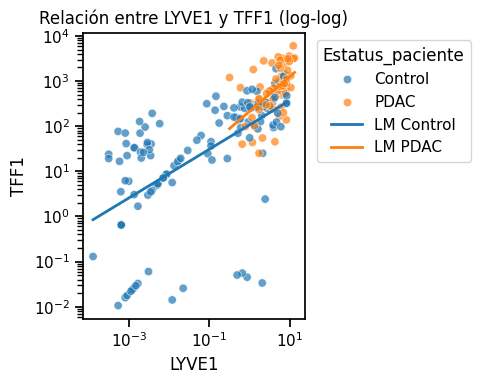

/tmp/ipython-input-3747229767.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for grupo, df_g in train_df[[xvar, yvar, "Estatus_paciente"]].dropna().groupby("Estatus_paciente"):


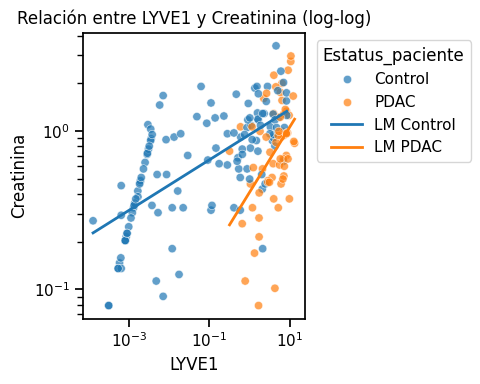

/tmp/ipython-input-3747229767.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for grupo, df_g in train_df[[xvar, yvar, "Estatus_paciente"]].dropna().groupby("Estatus_paciente"):


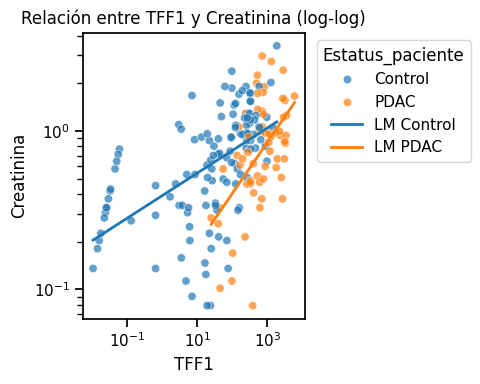

In [ ]:
# Scatterplots log-log con recta lm
pares = [("LYVE1","TFF1"), ("LYVE1","Creatinina"), ("TFF1","Creatinina")]

for xvar, yvar in pares:
    plt.figure(figsize=(5,4))
    ax = sns.scatterplot(
        data=train_df, x=xvar, y=yvar,
        hue="Estatus_paciente", alpha=0.7
    )

    # Ajuste por grupo (una recta por PDAC y otra por Control)
    for grupo, df_g in train_df[[xvar, yvar, "Estatus_paciente"]].dropna().groupby("Estatus_paciente"):
        # Solo valores positivos (necesario para log10)
        df_g = df_g[(df_g[xvar] > 0) & (df_g[yvar] > 0)].copy()
        if len(df_g) < 2:
            continue

        lx = np.log10(df_g[xvar].values)
        ly = np.log10(df_g[yvar].values)

        b1, b0, r, p, se = stats.linregress(lx, ly)

        xs = np.linspace(df_g[xvar].min(), df_g[xvar].max(), 100)
        ys = 10**(b0 + b1*np.log10(xs))

        # label para que aparezca en la leyenda
        ax.plot(xs, ys, linewidth=2, label=f"LM {grupo}")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(f"Relación entre {xvar} y {yvar} (log-log)")

    # Para que no se duplique la leyenda (puntos + líneas)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, title="Estatus_paciente", bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()
    plt.show()

**Forward manual**

In [ ]:
# Modelo nulo + deviance comparativa
mod_nulo = fit_logit("y_pdac ~ 1", train_df)

devs = {
    "nulo": mod_nulo.deviance,
    "sexo": mod_sexo.deviance,
    "edad": mod_edad.deviance,
    "creat": mod_creat.deviance,
    "lyve1": mod_lyve1.deviance,
    "reg1b": mod_reg1b.deviance,
    "tff1": mod_tff1.deviance
}
pd.Series(devs).sort_values()

,0
lyve1,166.457531
tff1,170.351523
reg1b,197.534432
edad,205.687355
sexo,233.265502
creat,240.364972
nulo,242.213726


El modelo nulo (sin covariables) presenta una deviance de 242,2, que sirve como punto de referencia para evaluar la ganancia explicativa al incorporar predictores individuales.

Entre los modelos univariados evaluados:

`LYVE1` muestra la menor deviance. `TFF1` y `REG1B` también producen reducciones importantes en la deviance, aunque menores que `LYVE1`. `Creatinina` presenta una reducción mínima de la deviance.

In [ ]:
# Paso 1 (base=LYVE1) + candidatos 2da variable
mod1 = mod_lyve1

mod2_edad  = fit_logit("y_pdac ~ LYVE1 + Edad", train_df)
mod2_sexo  = fit_logit("y_pdac ~ LYVE1 + C(Sexo)", train_df)
mod2_creat = fit_logit("y_pdac ~ LYVE1 + Creatinina", train_df)
mod2_reg1b = fit_logit("y_pdac ~ LYVE1 + REG1B", train_df)
mod2_tff1  = fit_logit("y_pdac ~ LYVE1 + TFF1", train_df)

pd.Series({
    "base": mod1.deviance,
    "edad": mod2_edad.deviance,
    "sexo": mod2_sexo.deviance,
    "creat": mod2_creat.deviance,
    "reg1b": mod2_reg1b.deviance,
    "tff1": mod2_tff1.deviance
}).sort_values()

,0
edad,144.443412
tff1,152.841628
creat,156.156609
reg1b,161.959780
sexo,163.631122
base,166.457531


`Edad` es la variable que genera la mayor reducción adicional de la deviance, pasando de 239,29 a **144,4**.

In [ ]:
def lrt_glm(reduced, full):
    """
    Likelihood Ratio Test (LRT) para modelos GLM binomial (statsmodels).
    reduced: modelo anidado (más simple)
    full: modelo más complejo
    """
    lr_stat = 2 * (full.llf - reduced.llf)
    df_diff = int(full.df_model - reduced.df_model)
    p_value = 1 - stats.chi2.cdf(lr_stat, df_diff)
    return {"LR_stat": float(lr_stat), "df": df_diff, "p_value": float(p_value)}

In [ ]:
# LRT: mod1 vs mod2
mod1 = mod_lyve1
mod2 = mod2_edad   # y_pdac ~ LYVE1 + Edad

lrt_glm(mod1, mod2)

{'LR_stat': 22.014118753630044, 'df': 1, 'p_value': 2.7065219555533204e-06}

El Likelihood Ratio Test (LRT) compara el modelo base con `LYVE1` frente al modelo ampliado que incorpora `Edad`. El resultado del test indica que la inclusión de la variable `Edad` produce una mejora estadísticamente significativa del ajuste del modelo (p < 0,001). Se rechaza la hipótesis nula de que el modelo con `LYVE1` y el modelo con `LYVE1 + Edad` tengan la misma capacidad explicativa, y se selecciona como nuevo modelo candidato **y_pdac ~ LYVE1 + Edad**.

In [ ]:
# Paso 2: incorporación de la tercera variable
mod3_creat = fit_logit("y_pdac ~ LYVE1 + Edad + Creatinina", train_df)
mod3_sexo  = fit_logit("y_pdac ~ LYVE1 + Edad + C(Sexo)", train_df)
mod3_reg1b = fit_logit("y_pdac ~ LYVE1 + Edad + REG1B", train_df)
mod3_tff1  = fit_logit("y_pdac ~ LYVE1 + Edad + TFF1", train_df)

pd.Series({
    "base": mod2.deviance,
    "creat": mod3_creat.deviance,
    "sexo": mod3_sexo.deviance,
    "reg1b": mod3_reg1b.deviance,
    "tff1": mod3_tff1.deviance
}).sort_values()

,0
tff1,131.198941
creat,138.953427
sexo,140.185651
reg1b,141.993918
base,144.443412


Entre las variables evaluadas, `TFF1` es la que produce la mayor reducción adicional de la deviance respecto del modelo base.

In [ ]:
mod2 = mod2_edad
mod3 = mod3_tff1

lrt_glm(mod2, mod3)

{'LR_stat': 13.244471297936684, 'df': 1, 'p_value': 0.00027338500731610704}

El LRT confirma que la incorporación de `TFF1` al modelo con `LYVE1 `y `Edad` mejora de forma estadísticamente significativa el ajuste del modelo (p < 0,001). Por lo tanto, se rechaza la hipótesis nula de equivalencia entre modelos y se selecciona como nuevo modelo candidato **Modelo 3: y_pdac ~ LYVE1 + Edad + TFF1**.

In [ ]:
# Paso 3: incorporación de la cuarta variable
mod4_creat = fit_logit("y_pdac ~ LYVE1 + Edad + TFF1 + Creatinina", train_df)
mod4_sexo  = fit_logit("y_pdac ~ LYVE1 + Edad + TFF1 + C(Sexo)", train_df)
mod4_reg1b = fit_logit("y_pdac ~ LYVE1 + Edad + TFF1 + REG1B", train_df)

pd.Series({
    "creat": mod4_creat.deviance,
    "sexo": mod4_sexo.deviance,
    "reg1b": mod4_reg1b.deviance
}).sort_values()

,0
creat,120.395528
sexo,127.493120
reg1b,131.120266


Entre las variables evaluadas en este paso, `Creatinina` es la que genera la mayor reducción adicional de la deviance respecto del modelo base (LYVE1 + Edad + TFF1).

In [ ]:
mod3 = mod3_tff1
mod4 = mod4_creat

lrt_glm(mod3, mod4)

{'LR_stat': 10.803412701137503, 'df': 1, 'p_value': 0.0010131315504120497}

El LRT confirma que la incorporación de `Creatinina` al modelo con `LYVE1`, `Edad` y `TFF1` produce una mejora estadísticamente significativa del ajuste (p < 0,001). Por lo tanto, se rechaza la hipótesis nula de equivalencia entre modelos y se selecciona como nuevo modelo candidato **Modelo 4: y_pdac ~ LYVE1 + Edad + TFF1 + Creatinina**.

In [ ]:
# Paso 4: evaluación de la quinta variable (Sexo)
mod5_sexo = fit_logit("y_pdac ~ LYVE1 + Edad + TFF1 + Creatinina + C(Sexo)", train_df)

{"AIC_mod4": mod4.aic, "AIC_mod5": mod5_sexo.aic, "dev_mod4": mod4.deviance, "dev_mod5": mod5_sexo.deviance}

{'AIC_mod4': np.float64(130.3955282277194),
 'AIC_mod5': np.float64(127.51138062948904),
 'dev_mod4': np.float64(120.39552822771944),
 'dev_mod5': np.float64(115.51138062948903)}

La incorporación de Sexo produce una reducción adicional de la deviance y una mejora del AIC. Ambos criterios sugieren una mejora modesta del ajuste.

In [ ]:
mod4 = mod4_creat
mod5 = mod5_sexo

lrt_glm(mod4, mod5)

{'LR_stat': 4.884147598230385, 'df': 1, 'p_value': 0.027104414926501286}

El LRT indica que la incorporación de `Sexo` mejora el ajuste del modelo de manera estadísticamente significativa al nivel α = 0,05.

In [ ]:
# Evaluación tipo drop1 (contribución marginal de cada término)
# Eliminación de un término a la vez y comparación mediante LRT.
def drop1_lrt(model_full, terms, df):
    """
    Drop1 aproximado (tipo R drop1(..., test="Chisq")) para GLM binomial:
    - Re-ajusta el modelo quitando 1 término por vez
    - Compara reduced vs full usando lrt_glm(reduced, full)
    """
    out = []
    for term in terms:
        reduced_terms = [t for t in terms if t != term]
        formula_red = "y_pdac ~ " + " + ".join(reduced_terms) if reduced_terms else "y_pdac ~ 1"

        m_red = fit_logit(formula_red, df)  # sigue siendo GLM binomial
        res = lrt_glm(m_red, model_full)  # <-- acá está el cambio (sin compare_lr_test)
        if isinstance(res, dict):
            lr = res["LR_stat"]; dfd = res["df"]; p = res["p_value"]
        else:
            lr, dfd, p = res
        out.append({
            "drop": term,
            "LR_stat": float(lr),
            "df": int(dfd),
            "p_value": float(p),
            "AIC_reduced": float(m_red.aic),
            "AIC_full": float(model_full.aic),
            "Deviance_reduced": float(m_red.deviance),
            "Deviance_full": float(model_full.deviance),
            "Delta_Deviance": float(m_red.deviance - model_full.deviance)  # >0 mejora el full
        })

    return pd.DataFrame(out).sort_values("p_value")

terms_mod5 = ["LYVE1", "Edad", "TFF1", "Creatinina", "C(Sexo)"]
drop1_lrt(mod5_sexo, terms_mod5, train_df)

,drop,LR_stat,df,p_value,AIC_reduced,AIC_full,Deviance_reduced,Deviance_full,Delta_Deviance
2,TFF1,18.034162,1,0.000022,143.545542,127.511381,133.545542,115.511381,18.034162
0,LYVE1,17.647236,1,0.000027,143.158616,127.511381,133.158616,115.511381,17.647236
1,Edad,16.655113,1,0.000045,142.166493,127.511381,132.166493,115.511381,16.655113
3,Creatinina,11.981739,1,0.000537,137.493120,127.511381,127.493120,115.511381,11.981739
4,C(Sexo),4.884148,1,0.027104,130.395528,127.511381,120.395528,115.511381,4.884148


El análisis muestra que `LYVE1`, `TFF1`, `Creatinina` y `Edad` son importantes para el modelo y su eliminación produce pérdidas sustanciales en el ajuste. El efecto del sexo, si bien estadísticamente detectable, es secundario frente al aporte de los biomarcadores y la edad.

In [ ]:
# Evaluación de interacciones: LYVE1 × TFF1
mod5 = mod5_sexo
mod6 = fit_logit("y_pdac ~ LYVE1 + Edad + TFF1 + Creatinina + C(Sexo) + LYVE1:TFF1", train_df)

{"AIC_mod5": mod5.aic, "AIC_mod6": mod6.aic}

{'AIC_mod5': np.float64(127.51138062948904),
 'AIC_mod6': np.float64(126.22364213156507)}

La inclusión del término de interacción LYVE1 × TFF1 produce una reducción del AIC (ΔAIC ≈ −1,3), lo que indica una mejora del ajuste del modelo.

In [ ]:
lrt_glm(mod5, mod6)

{'LR_stat': 3.287738497923968, 'df': 1, 'p_value': 0.06979909821526387}

La interacción `LYVE1×TFF1` reduce AIC pero el LRT no alcanza significación al 5% (p≈0.07), por lo que no se incorpora bajo criterio α=0.05.

In [ ]:
# Reevaluación de Sexo: ¿aporta si mantenemos la interacción?
# mod7: SIN Sexo (pero CON interacción)
mod7 = fit_logit("y_pdac ~ LYVE1 + Edad + TFF1 + Creatinina + LYVE1*TFF1", train_df)

# LRT: reduced vs full (siempre en este orden)
res_sexo = lrt_glm(mod7, mod6)

print("LRT (Sexo | interacción):", res_sexo)
print({"AIC_mod7": float(mod7.aic), "AIC_mod6": float(mod6.aic)})

LRT (Sexo | interacción): {'LR_stat': 3.6499887073462105, 'df': 1, 'p_value': 0.05606959161809544}
{'AIC_mod7': 127.87363083891128, 'AIC_mod6': 126.22364213156507}


Se evaluó la contribución adicional del sexo una vez incorporada la interacción entre LYVE1 y TFF1. El test de razón de verosimilitudes no mostró evidencia estadísticamente significativa al nivel del 5% (LR = 3,65; gl = 1; p = 0,056).

Se selecciona como modelo final del enfoque forward **y_pdac ~ LYVE1 + Edad + TFF1 + Creatinina + LYVE1*TFF1**

**Selección de variables: estrategia Backward manual**

In [ ]:
# Modelo saturado inicial
mod_full = fit_logit("y_pdac ~ Edad + C(Sexo) + Creatinina + LYVE1 + REG1B + TFF1", train_df)
print(mod_full.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 y_pdac   No. Observations:                  191
Model:                            GLM   Df Residuals:                      184
Model Family:                Binomial   Df Model:                            6
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -57.752
Date:                Wed, 07 Jan 2026   Deviance:                       115.50
Time:                        14:59:31   Pearson chi2:                     299.
No. Iterations:                     7   Pseudo R-squ. (CS):             0.4849
Covariance Type:            nonrobust                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -7.6698      1.709  

El modelo saturado incluye todas las covariables principales (demográficas y biomarcadores). A partir del resumen se observa que `Edad`, `Creatinina`, `LYVE1`, `TFF1` y `Sexo` presentan asociaciones estadísticamente significativas con PDAC y `REG1B` no muestra asociación alguna (p ≈ 0,998).

In [ ]:
# Análisis tipo drop1 (LRT)
terms_full = ["Edad","C(Sexo)","Creatinina","LYVE1","REG1B","TFF1"]
drop1_lrt(mod_full, terms_full, datos)

,drop,LR_stat,df,p_value,AIC_reduced,AIC_full,Deviance_reduced,Deviance_full,Delta_Deviance
3,LYVE1,23.705576,1,0.000001,225.355673,203.650097,213.355673,189.650097,23.705576
5,TFF1,17.759137,1,0.000025,219.409233,203.650097,207.409233,189.650097,17.759137
2,Creatinina,13.742706,1,0.000210,215.392803,203.650097,203.392803,189.650097,13.742706
0,Edad,11.758773,1,0.000606,213.408870,203.650097,201.408870,189.650097,11.758773
1,C(Sexo),3.765133,1,0.052332,205.415229,203.650097,193.415229,189.650097,3.765133
4,REG1B,0.000009,1,0.997571,201.650106,203.650097,189.650106,189.650097,0.000009


El análisis drop1 indica que `Sexo` tiene una contribución marginal y `REG1B` no aporta información adicional. Es el principal candidato a ser eliminado en el proceso backward.

In [ ]:
# Eliminación de REG1B y evaluación de interacción
mod_1 = fit_logit("y_pdac ~ Edad + C(Sexo) + Creatinina + LYVE1 + TFF1", datos)

mod_int = fit_logit("y_pdac ~ Edad + Creatinina + C(Sexo) + TFF1 + LYVE1 + LYVE1*TFF1", datos)

{"AIC_mod1": mod_1.aic, "AIC_int": mod_int.aic}

{'AIC_mod1': np.float64(201.6501059684109),
 'AIC_int': np.float64(195.61510660762536)}

In [ ]:
lrt_glm(mod_1, mod_int)

{'LR_stat': 8.034999360785548, 'df': 1, 'p_value': 0.004588202637920369}

La incorporación del término de interacción `LYVE1 × TFF1` mejora de manera estadísticamente significativa el ajuste del modelo (p < 0,01), en concordancia con lo observado en la estrategia forward.

In [ ]:
# Reevaluación de la variable Sexo en el modelo con interacción
mod_int_sin_sexo = fit_logit("y_pdac ~ Edad + Creatinina + TFF1 + LYVE1 + LYVE1*TFF1", datos)
lrt_glm(mod_int_sin_sexo, mod_int)

{'LR_stat': 2.7034169339128766, 'df': 1, 'p_value': 0.10013343424533461}

Confirma que `Sexo` no mejora significativamente el ajuste en presencia de la interacción `LYVE1 × TFF1`.

In [ ]:
# Comparación global de modelos candidatos
def mcfadden_r2(model):
    # 1 - (ll_full / ll_null)
    llf = model.llf
    lln = model.null_deviance / (-2)  # porque deviance = -2*ll + const; statsmodels ya tiene null_deviance
    # OJO: mejor usar llnull directo:
    # statsmodels GLMResults tiene .llnull
    lln = model.llnull
    return 1 - (llf / lln)

pd.DataFrame({
    "modelo": ["mod_1","mod_int","mod_int_sin_sexo"],
    "AIC": [mod_1.aic, mod_int.aic, mod_int_sin_sexo.aic],
    "Deviance": [mod_1.deviance, mod_int.deviance, mod_int_sin_sexo.deviance],
    "McFadden_R2": [mcfadden_r2(mod_1), mcfadden_r2(mod_int), mcfadden_r2(mod_int_sin_sexo)]
}).sort_values("AIC")

,modelo,AIC,Deviance,McFadden_R2
1,mod_int,195.615107,181.615107,0.478636
2,mod_int_sin_sexo,196.318524,184.318524,0.470875
0,mod_1,201.650106,189.650106,0.455569


El modelo con interacción `LYVE1 × TFF1` muestra una mejora sustancial respecto del modelo sin interacción. Dado que `Sexo` no es significativo en presencia de la interacción, su exclusión genera un aumento mínimo del AIC (ΔAIC ≈ +0,7), genera una reducción muy pequeña del R² de McFadden, y el objetivo es encontrar el modelo de mayor parsimonia, se prioriza el modelo sin Sexo.

In [ ]:
# Modelo final seleccionado
mod_final = mod_int_sin_sexo
print(mod_final.summary())
or_table(mod_final).round(3)

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 y_pdac   No. Observations:                  274
Model:                            GLM   Df Residuals:                      268
Model Family:                Binomial   Df Model:                            5
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -92.159
Date:                Wed, 07 Jan 2026   Deviance:                       184.32
Time:                        13:54:15   Pearson chi2:                     360.
No. Iterations:                     6   Pseudo R-squ. (CS):             0.4504
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -5.3625      1.216     -4.411      0.0

,coef,OR,CI2.5,CI97.5,p_value
Intercept,-5.362,0.005,0.000,0.051,0.000
Edad,0.055,1.057,1.020,1.094,0.002
Creatinina,-1.461,0.232,0.108,0.500,0.000
TFF1,0.004,1.004,1.002,1.006,0.000
LYVE1,0.592,1.807,1.489,2.192,0.000
LYVE1:TFF1,-0.000,1.000,0.999,1.000,0.000


logit(π)=β0​+β1​⋅Edad+β2​⋅Creatinina+β3​⋅TFF1+β4​⋅LYVE1+β5​⋅(LYVE1×TFF1)

Interpretación del modelo final:

*   `Edad` se asocia positivamente con PDAC: cada año adicional incrementa las odds en ~6%.
*   `Creatinina` presenta un efecto inverso, actuando como factor de ajuste en el contexto multivariado.
*   `LYVE1` y `TFF1` son fuertes predictores positivos de PDAC.
*   El término de interacción `LYVE1 × TFF1` es negativo y significativo, lo que indica que el efecto de LYVE1 sobre el riesgo de PDAC disminuye a medida que aumentan los valores de TFF1, y viceversa.

**Diagnóstico del modelo final**

In [ ]:
# Residuos estandarizados (studentized)
infl = mod_final.get_influence()
datos["rstandar"] = infl.resid_studentized  # análogo práctico a rstandard
datos["rstandar"].describe()

,rstandar
count,274.000000
mean,-0.009511
std,1.157510
min,-8.557561
25%,-0.365208
50%,-0.210536
75%,0.184956
max,9.901503


Los residuos estandarizados presentan una media cercana a cero. La mayoría de las observaciones se concentran dentro de rangos moderados, aunque se observan algunos valores extremos.

In [ ]:
# Identificación de observaciones potencialmente problemáticas: conteo de observaciones con |rstandar| > umbrales
def count_rstandar(df):
    def grp(x):
        ax = abs(x)
        if ax > 3: return ">3"
        if ax > 2.5: return ">2.5"
        if ax > 2: return ">2"
        return "≤2"
    return df.assign(grupo=df["rstandar"].apply(grp)).groupby("grupo").size().sort_index()

count_rstandar(train_df)

,0
grupo,
>2,3
>3,4
≤2,184


La gran mayoría de las observaciones (≈ 95%) presentan residuos estandarizados dentro de ±2, lo que indica un ajuste global adecuado.

In [ ]:
final_formula = "y_pdac ~ Edad + Creatinina + TFF1 + LYVE1 + LYVE1*TFF1"

# Ajuste final solo en train
mod_final_train = fit_logit(final_formula, train_df)
print(mod_final_train.summary())
display(or_table(mod_final_train).round(4))

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 y_pdac   No. Observations:                  191
Model:                            GLM   Df Residuals:                      185
Model Family:                Binomial   Df Model:                            5
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -57.937
Date:                Wed, 07 Jan 2026   Deviance:                       115.87
Time:                        15:04:37   Pearson chi2:                     317.
No. Iterations:                     7   Pseudo R-squ. (CS):             0.4839
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -7.2991      1.699     -4.296      0.0

,coef,OR,CI2.5,CI97.5,p_value
Intercept,-7.2991,0.0007,0.0000,0.0189,0.0000
Edad,0.0836,1.0872,1.0365,1.1405,0.0006
Creatinina,-1.5417,0.2140,0.0823,0.5566,0.0016
TFF1,0.0041,1.0041,1.0019,1.0064,0.0003
LYVE1,0.6403,1.8970,1.4567,2.4705,0.0000
LYVE1:TFF1,-0.0003,0.9997,0.9994,0.9999,0.0055


,rstandar
count,191.000000
mean,-0.086715
std,1.301379
min,-13.948518
25%,-0.323495
50%,-0.161113
75%,0.131130
max,4.773855


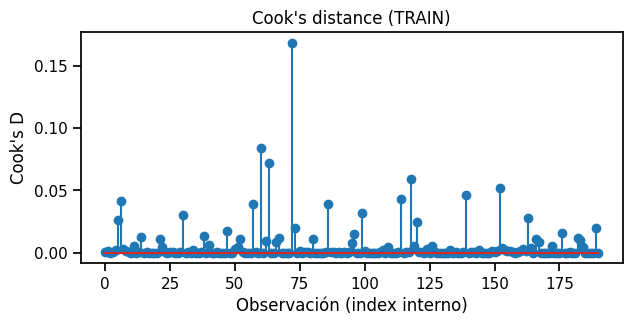

Umbral 4/n: 0.020942408376963352
N obs con Cook > 4/n: 15


In [ ]:
# Cook + residuos
infl = mod_final_train.get_influence()
train_df = train_df.copy()
train_df["rstandar"] = infl.resid_studentized
display(train_df["rstandar"].describe())

cooks = infl.cooks_distance[0]
plt.figure(figsize=(7,3))
plt.stem(np.arange(len(cooks)), cooks)
plt.title("Cook's distance (TRAIN)")
plt.xlabel("Observación (index interno)")
plt.ylabel("Cook's D")
plt.show()

thr = 4 / len(train_df)
print("Umbral 4/n:", thr)
print("N obs con Cook > 4/n:", int((cooks > thr).sum()))

In [ ]:
# Colinealidad entre covariables (VIF)
X = mod_final_train.model.exog
vif = pd.DataFrame({
    "variable": mod_final_train.model.exog_names,
    "VIF": [variance_inflation_factor(X, i) for i in range(X.shape[1])]
})
display(vif)

,variable,VIF
0,Intercept,31.744529
1,Edad,1.174573
2,Creatinina,1.370335
3,TFF1,6.562980
4,LYVE1,2.519969
5,LYVE1:TFF1,7.009003


`TFF1` y el término de interacción `LYVE1 × TFF1` presentan valores de VIF moderados (≈ 6–7), esperable porque los términos de interacción están matemáticamente correlacionados con sus efectos principales.

In [ ]:
# Pseudo-R² (McFadden, Cox-Snell, Nagelkerke, Tjur)
def pseudo_r2_all(model, y_true):
    n = len(y_true)
    llf = model.llf
    llnull = model.llnull

    # McFadden
    r2_mcf = 1 - (llf / llnull)

    # Cox-Snell y Nagelkerke
    r2_cs = 1 - np.exp((2/n) * (llnull - llf))
    r2_nk = r2_cs / (1 - np.exp((2/n) * llnull))

    # Tjur: diferencia entre medias de p_hat en y=1 y y=0
    phat = model.predict()
    r2_tjur = phat[y_true==1].mean() - phat[y_true==0].mean()

    return {
        "McFadden": r2_mcf,
        "CoxSnell": r2_cs,
        "Nagelkerke": r2_nk,
        "Tjur": r2_tjur
    }

pseudo_r2_all(mod_final, datos["y_pdac"].values)

{'McFadden': np.float64(0.47087491141236515),
 'CoxSnell': np.float64(0.45044138532923583),
 'Nagelkerke': np.float64(0.6260102998790384),
 'Tjur': np.float64(0.5416265791129665)}

In [ ]:
# Bondad de ajuste: prueba de Hosmer–Lemeshow
def hosmer_lemeshow(y, p, g=10):
    df = pd.DataFrame({"y": y, "p": p}).dropna()
    df["bin"] = pd.qcut(df["p"], q=g, duplicates="drop")
    obs = df.groupby("bin", observed=False)["y"].agg(["sum","count"])
    obs.columns = ["events","n"]
    obs["nonevents"] = obs["n"] - obs["events"]
    exp_events = df.groupby("bin", observed=False)["p"].sum()
    exp_nonevents = obs["n"] - exp_events

    hl = (((obs["events"] - exp_events)**2) / (exp_events + 1e-12) +
          ((obs["nonevents"] - exp_nonevents)**2) / (exp_nonevents + 1e-12)).sum()

    dof = obs.shape[0] - 2
    pval = 1 - stats.chi2.cdf(hl, dof)
    return {"HL_stat": float(hl), "df": int(dof), "p_value": float(pval), "groups_used": int(obs.shape[0])}

p_hat_train = mod_final_train.predict(train_df)
print("HL TRAIN g=10:", hosmer_lemeshow(train_df["y_pdac"].values, p_hat_train, g=10))
print("HL TRAIN g=7 :", hosmer_lemeshow(train_df["y_pdac"].values, p_hat_train, g=7))

HL TRAIN g=10: {'HL_stat': 11.357518953714257, 'df': 8, 'p_value': 0.18225274411304815, 'groups_used': 10}
HL TRAIN g=7 : {'HL_stat': 3.3360526021838086, 'df': 5, 'p_value': 0.6483267301441298, 'groups_used': 7}


En el modelo final se obtuvo HL = 11,6 con gl = 8 y p = 0,18. Dado que el valor p es muy superior a 0,05, no se rechaza la hipótesis nula de buen ajuste.

**Desempeño predictivo: curva ROC y AUC**

In [ ]:
# Predicciones del modelo
test_pred = test_df.copy()
test_pred["prob"] = mod_final_train.predict(test_pred)

# AUC en TEST
auc_test = roc_auc_score(test_pred["y_pdac"], test_pred["prob"])
print("AUC (TEST):", auc_test)

AUC (TEST): 0.8422077922077923


El modelo final alcanza un **AUC = 0,842**, lo que indica una muy buena capacidad discriminativa. Esto significa que, en el 84,2% de los pares aleatorios formados por un paciente con PDAC y un control, el modelo asigna una probabilidad mayor al paciente con PDAC.

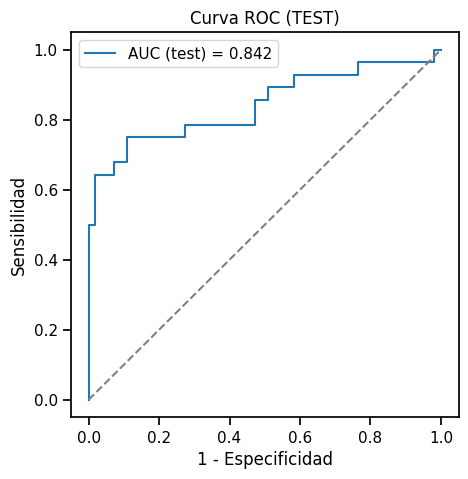

In [ ]:
# ROC en TEST
fpr, tpr, thr = roc_curve(test_pred["y_pdac"], test_pred["prob"])
plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f"AUC (test) = {auc_test:.3f}")
plt.plot([0,1],[0,1],"--", color="grey")
plt.xlabel("1 - Especificidad")
plt.ylabel("Sensibilidad")
plt.title("Curva ROC (TEST)")
plt.legend()
plt.show()

In [ ]:
# Prueba de cutoffs
def metrics_by_cutoff(y_true, prob, cutoff):
    pred = (prob >= cutoff).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    return {
        "cutoff": cutoff,
        "sensibilidad": tp / (tp + fn) if (tp+fn)>0 else np.nan,
        "especificidad": tn / (tn + fp) if (tn+fp)>0 else np.nan,
        "falsos_negativos": int(fn),
        "falsos_positivos": int(fp)
    }

cutoffs = [0.5, 0.3, 0.2, 0.1]
tab_cut = pd.DataFrame([metrics_by_cutoff(test_pred["y_pdac"].values, test_pred["prob"].values, c) for c in cutoffs])
display(tab_cut)

,cutoff,sensibilidad,especificidad,falsos_negativos,falsos_positivos
0,0.5,0.642857,0.963636,10,2
1,0.3,0.750000,0.854545,7,8
2,0.2,0.750000,0.781818,7,12
3,0.1,0.857143,0.527273,4,26


Dado que el objetivo del modelo es su uso potencial como prueba de tamizaje, se evaluó el desempeño bajo distintos puntos de corte, priorizando la sensibilidad por sobre la especificidad.

Al reducir el punto de corte de 0,5 a 0,2, la sensibilidad aumenta al 75%, con una levemente superior (78%), logrando un balance entre detección de casos y tasa de falsos positivos. Una sensibilidad mayor (lograda con un cutoff de 0,1) arrojaría muchos falsos negativos.

In [ ]:
# Clasificación con punto de corte 0,3
cutoff = 0.2
test_pred["pred"] = (test_pred["prob"] >= cutoff).astype(int)

cm = confusion_matrix(test_pred["y_pdac"], test_pred["pred"])
print("Matriz de confusión (TEST), cutoff=0.3:\n", cm)

Matriz de confusión (TEST), cutoff=0.3:
 [[43 12]
 [ 7 21]]


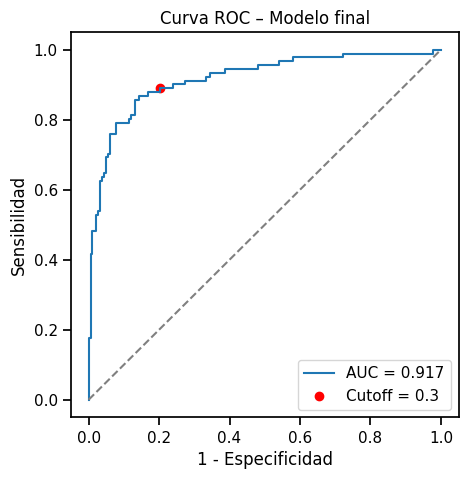

In [ ]:
# Curva ROC con cutoff 0,3
fpr, tpr, thr = roc_curve(df_pred["y_pdac"], df_pred["prob"])

plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],"--", color="grey")

# marcar cutoff 0.3
idx = np.argmin(np.abs(thr - 0.2))
plt.scatter(fpr[idx], tpr[idx], color="red", label="Cutoff = 0.3")

plt.xlabel("1 - Especificidad")
plt.ylabel("Sensibilidad")
plt.legend()
plt.title("Curva ROC – Modelo final")
plt.show()

In [ ]:
# Métricas de desempeño

tn, fp, fn, tp = cm.ravel()
sensibilidad = tp / (tp + fn) if (tp+fn)>0 else np.nan
especificidad = tn / (tn + fp) if (tn+fp)>0 else np.nan
vpp = tp / (tp + fp) if (tp+fp)>0 else np.nan
vpn = tn / (tn + fn) if (tn+fn)>0 else np.nan
exactitud = accuracy_score(test_pred["y_pdac"], test_pred["pred"])

print({
    "cutoff": cutoff,
    "sensibilidad": round(sensibilidad, 3),
    "especificidad": round(especificidad, 3),
    "VPP": round(vpp, 3),
    "VPN": round(vpn, 3),
    "exactitud": round(exactitud, 3),
    "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp)
})

{'cutoff': 0.2, 'sensibilidad': np.float64(0.75), 'especificidad': np.float64(0.782), 'VPP': np.float64(0.636), 'VPN': np.float64(0.86), 'exactitud': 0.771, 'TN': 43, 'FP': 12, 'FN': 7, 'TP': 21}


El valor predictivo negativo elevado (0,86%) es particularmente relevante en este contexto, ya que indica una alta probabilidad de descartar correctamente PDAC cuando el test resulta negativo.

### **Conclusiones**

En este trabajo se desarrolló un modelo de regresión logística para la predicción de cáncer de páncreas (PDAC) a partir de variables demográficas y biomarcadores.

Los resultados muestran que la edad y los biomarcadores LYVE1 y TFF1 se asocian de manera significativa con la presencia de PDAC, mientras que la creatinina presenta un efecto independiente con signo negativo. La inclusión de un término de interacción entre LYVE1 y TFF1 permitió capturar una relación no aditiva entre ambos biomarcadores, mejorando levemente el desempeño global del modelo y aportando coherencia biológica.

El modelo final muestra una buena capacidad discriminativa, con un área bajo la curva ROC (AUC) elevado, y un buen ajuste global. En un escenario de tamizaje, la evaluación de distintos puntos de corte se hizo prorizando la sensibilidad, reduciendo el número de falsos negativos a expensas de un aumento controlado de falsos positivos.